# Decision Tree Classifier

## Objective

The objective of this experiment is to train a Decision Tree classifier on the Titanic dataset and compare its performance with the Logistic Regression model.

In this experiment, we will evaluate the model using Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score,precision_score, recall_score,f1_score)

from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

##Loading Dataset

In [ ]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Check dataset information
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#Data Preprocessing
Missing values are handled and categorical variables are converted into numerical format.

In [ ]:
df = pd.read_csv("Titanic-Dataset.csv")

df['Age'] = df['Age'].fillna(df['Age'].median())

df['Fare'] = df['Fare'].fillna(df['Fare'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


### Encoding Categorical Variables

Machine learning algorithms cannot directly process text values.

Therefore, categorical features are converted into numerical representation using one-hot encoding.

In [ ]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,"Name_Abbott, Mr. Rossmore Edward","Name_Abbott, Mrs. Stanton (Rosa Hunt)","Name_Abelson, Mr. Samuel",...,Cabin_F G63,Cabin_F G73,Cabin_F2,Cabin_F33,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_T,Embarked_Q,Embarked_S
0,1,0,3,22.0,1,0,7.2500,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2,1,1,38.0,1,0,71.2833,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,1,3,26.0,0,0,7.9250,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,4,1,1,35.0,1,0,53.1000,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,5,0,3,35.0,0,0,8.0500,False,False,False,...,False,False,False,False,False,False,False,False,False,True


## Preparing Data for Training

The dataset is divided into features and target variable.

Features contain information about passengers, while the target variable represents the survival outcome.

In [ ]:
X = df.drop("Survived", axis=1)

y = df["Survived"]

## Splitting the Dataset

To evaluate the model performance, the dataset is divided into training and testing parts.

The training data is used to build the model, while the testing data is used to evaluate how well the model performs on unseen data.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
df[['Sex','Age','Fare']].isnull().sum()

,0
Sex,0
Age,0
Fare,0


##  Training the Decision Tree Model

A Decision Tree classifier is a supervised machine learning algorithm that makes decisions based on feature values.

Unlike Logistic Regression, Decision Tree can capture non-linear relationships between variables.

In [ ]:
decision_tree = DecisionTreeClassifier(random_state=42)

##The model is trained using the training dataset.

During this process, the Decision Tree learns patterns between passenger characteristics and survival outcomes.

In [ ]:
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

## Making Predictions

After training, the model is used to predict survival outcomes for passengers from the test dataset.

In [ ]:
y_pred_tree = decision_tree.predict(X_test)

##Decision Tree Performance

In [ ]:
Decision_Tree_accuracy = accuracy_score(y_test, y_pred_tree)
Decision_Tree_precision = precision_score(y_test, y_pred_tree)
Decision_Tree_recall = recall_score(y_test, y_pred_tree)
Decision_Tree_f1 = f1_score(y_test, y_pred_tree)


print("Accuracy:", round(Decision_Tree_accuracy, 3))
print("Precision:", round(Decision_Tree_precision, 3))
print("Recall:", round(Decision_Tree_recall, 3))
print("F1-score:", round(Decision_Tree_f1, 3))

Accuracy: 0.821
Precision: 0.839
Recall: 0.703
F1-score: 0.765


##Confusion Matrix
The confusion matrix provides a detailed overview of the model's predictions.

It shows how many passengers were correctly and incorrectly classified.

Unlike Accuracy, the confusion matrix helps identify specific types of errors, such as false positives and false negatives.

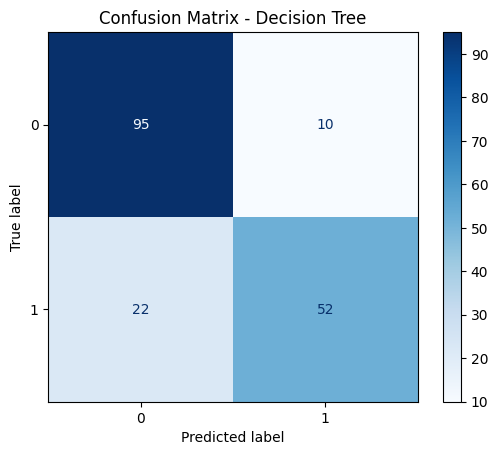

In [ ]:
cm = confusion_matrix(y_test, y_pred_tree)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Decision Tree")
plt.show()

## Model Performance Comparison

The performance of the Decision Tree classifier is compared with the Logistic Regression model from the previous experiment.

The comparison is based on Accuracy, Precision, Recall, and F1-score.          

In [ ]:
comparison = pd.DataFrame({"Model": ["Decision Tree", "Logistic Regression"], "Accuracy": [0.821, 0.816], "Precision": [0.839, 0.797], "Recall": [0.703, 0.743], "F1-score": [0.765, 0.769]})

comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.821,0.839,0.703,0.765
1,Logistic Regression,0.816,0.797,0.743,0.769


In [ ]:
matrix_table = pd.DataFrame({"Model":["Decision Tree", "Logistic Regression"],"True Negative": [95, 91],"False Positive": [10, 14],"False negative": [22, 19],"True Positive": [52, 55],})
matrix_table

,Model,True Negative,False Positive,False negative,True Positive
0,Decision Tree,95,10,22,52
1,Logistic Regression,91,14,19,55


## Analysis of Results

The results show that both Logistic Regression and Decision Tree achieved similar performance on the Titanic dataset.

Decision Tree achieved slightly higher Accuracy (0.821) and Precision (0.839), while Logistic Regression demonstrated higher Recall (0.743) and a similar F1-score (0.769).

The higher Precision of Decision Tree indicates that the model produced fewer false positive predictions, while Logistic Regression was better at identifying positive cases.

The confusion matrix analysis shows that both models have different prediction patterns, which demonstrates that model performance depends on the evaluation metric and the relationship between the algorithm and the dataset.

## Conclusion

In this experiment, the Decision Tree classifier was trained and compared with Logistic Regression using the Titanic dataset.

The results showed that Decision Tree achieved slightly higher Accuracy and Precision, while Logistic Regression provided better Recall and a comparable F1-score.

This experiment demonstrates that different machine learning algorithms can perform differently depending on the evaluation metric and dataset characteristics. A more complex model does not always guarantee better performance.